In [1]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

print("XAI libraries loaded successfully.")

XAI libraries loaded successfully.


In [2]:
df = pd.read_csv("../data/final_modeling_dataset.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()


Dataset loaded successfully.
Shape: (997, 15)


,PTID,MCI_DATE,AD_CONVERSION_2YR,AGE,PTGENDER,PTEDUCAT,PTETHCAT,PTRACCAT,APOE,CDGLOBAL,CDRSB,MMSCORE,LEFT_HIPPOCAMPUS_VOLUME,RIGHT_HIPPOCAMPUS_VOLUME,APOE_E4_CARRIER
0,002_S_0729,2006-08-03,1,65.2,Female,16.0,Not Hispanic or Latino,White,ε3/ε4,0.5,0.5,27.0,3172.8,3063.2,1.0
1,002_S_0782,2006-08-23,0,81.6,Male,16.0,Not Hispanic or Latino,White,ε3/ε3,0.5,0.5,29.0,2985.5,3735.7,0.0
2,002_S_0954,2006-11-22,1,69.4,Female,14.0,Not Hispanic or Latino,White,ε3/ε4,0.5,2.0,25.0,2599.6,2866.9,1.0
3,002_S_1070,2006-12-27,1,73.7,Male,14.0,Not Hispanic or Latino,White,ε3/ε3,0.5,2.5,25.0,4842.4,4664.6,0.0
4,002_S_1155,2007-01-10,0,57.9,Male,20.0,Not Hispanic or Latino,White,ε3/ε3,0.5,1.5,28.0,4058.5,4208.8,0.0


In [3]:
target = "AD_CONVERSION_2YR"

primary_features = [
    "AGE",
    "PTGENDER",
    "PTEDUCAT",
    "PTETHCAT",
    "PTRACCAT",
    "APOE",
    "CDGLOBAL",
    "CDRSB",
    "MMSCORE"
]

X = df[primary_features].copy()
y = df[target].copy()

print("Target:", target)
print("Number of features:", len(primary_features))
print("X shape:", X.shape)
print("y shape:", y.shape)

Target: AD_CONVERSION_2YR
Number of features: 9
X shape: (997, 9)
y shape: (997,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("\nTest target distribution:")
print(y_test.value_counts())

Training set: (797, 9)
Test set: (200, 9)

Test target distribution:
AD_CONVERSION_2YR
0    176
1     24
Name: count, dtype: int64


In [5]:
numeric_features = [
    "AGE",
    "PTEDUCAT",
    "CDGLOBAL",
    "CDRSB",
    "MMSCORE"
]

categorical_features = [
    "PTGENDER",
    "PTETHCAT",
    "PTRACCAT",
    "APOE"
]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

print("Preprocessing completed.")
print("Processed training shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)
print("Number of processed features:", len(feature_names))

Preprocessing completed.
Processed training shape: (797, 22)
Processed test shape: (200, 22)
Number of processed features: 22


In [6]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1]),
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train_processed, y_train)

print("XGBoost model recreated successfully.")

XGBoost model recreated successfully.


In [7]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

print("Random Forest model recreated successfully.")

Random Forest model recreated successfully.


In [8]:
from interpret.glassbox import ExplainableBoostingClassifier

ebm_model = ExplainableBoostingClassifier(
    interactions=0,
    random_state=42
)

ebm_model.fit(X_train_processed, y_train)


print("EBM model recreated successfully.")

EBM model recreated successfully.


In [9]:
print("Models ready for XAI analysis:")
print("1. XGBoost:", type(xgb_model).__name__)
print("2. Random Forest:", type(rf_model).__name__)
print("3. EBM:", type(ebm_model).__name__)

print("\nTest data shape:", X_test_processed.shape)
print("Feature count:", len(feature_names))

Models ready for XAI analysis:
1. XGBoost: XGBClassifier
2. Random Forest: RandomForestClassifier
3. EBM: ExplainableBoostingClassifier

Test data shape: (200, 22)
Feature count: 22


In [10]:
xgb_explainer = shap.TreeExplainer(xgb_model)

xgb_shap_values = xgb_explainer.shap_values(X_test_processed)

print("XGBoost SHAP analysis completed.")
print("SHAP shape:", xgb_shap_values.shape)

XGBoost SHAP analysis completed.
SHAP shape: (200, 22)


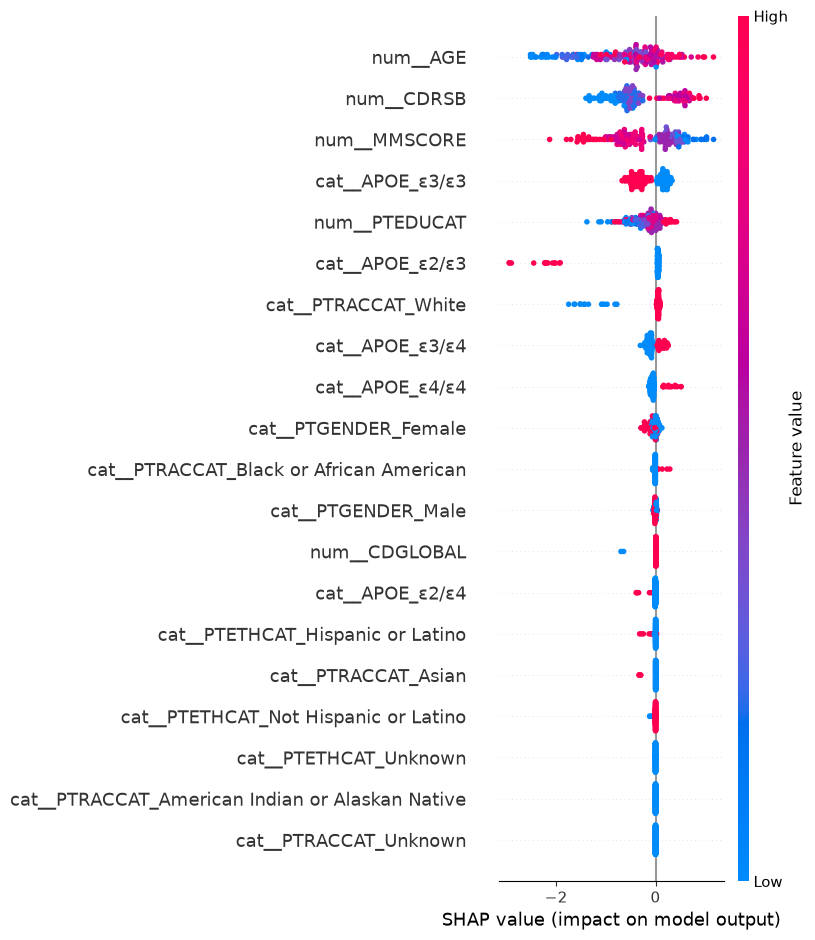

In [11]:
shap.summary_plot(
    xgb_shap_values,
    X_test_processed,
    feature_names=feature_names,
    show=True
)

In [12]:
xgb_shap_df = pd.DataFrame(
    xgb_shap_values,
    columns=feature_names
)

xgb_shap_df.to_csv(
    "../results/xgboost_shap_values.csv",
    index=False
)

print("XGBoost SHAP values saved successfully.")
print("Saved shape:", xgb_shap_df.shape)

XGBoost SHAP values saved successfully.
Saved shape: (200, 22)


In [13]:
rf_explainer = shap.TreeExplainer(rf_model)

rf_shap_values = rf_explainer.shap_values(X_test_processed)

print("Random Forest SHAP analysis completed.")
print("SHAP shape:", rf_shap_values.shape)

Random Forest SHAP analysis completed.
SHAP shape: (200, 22, 2)


In [14]:
rf_shap_class1 = rf_shap_values[:, :, 1]

print("Random Forest class-1 SHAP values selected.")
print("SHAP shape:", rf_shap_class1.shape)

Random Forest class-1 SHAP values selected.
SHAP shape: (200, 22)


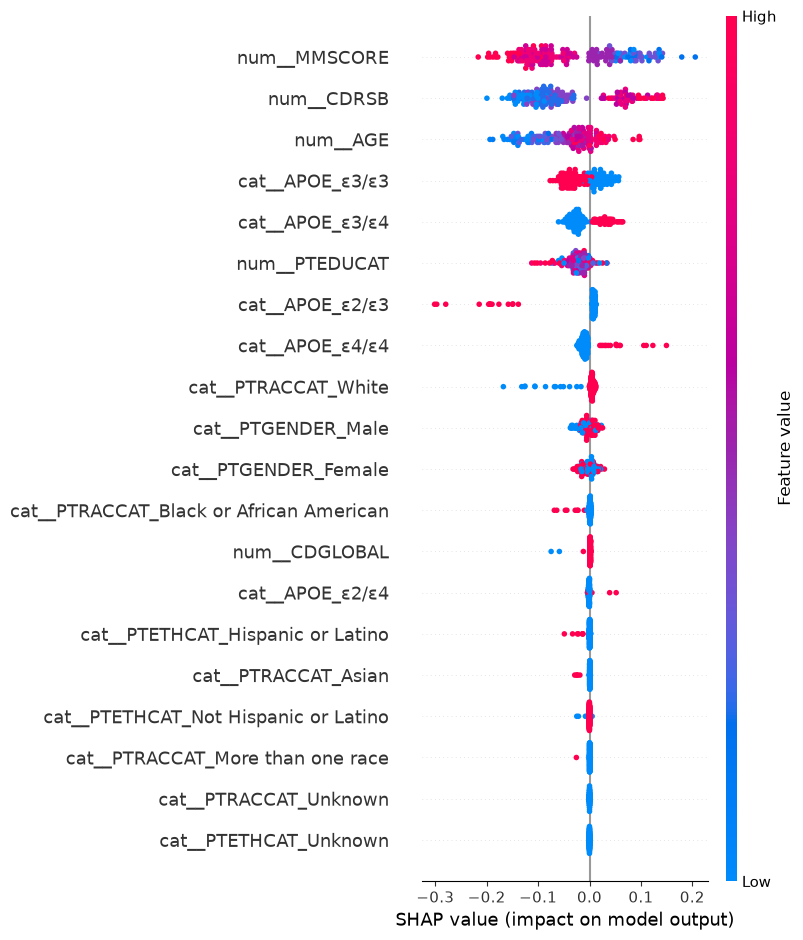

In [15]:
shap.summary_plot(
    rf_shap_class1,
    X_test_processed,
    feature_names=feature_names,
    show=True
)

In [16]:
rf_shap_df = pd.DataFrame(
    rf_shap_class1,
    columns=feature_names
)

rf_shap_df.to_csv(
    "../results/random_forest_shap_values.csv",
    index=False
)

print("Random Forest SHAP values saved successfully.")
print("Saved shape:", rf_shap_df.shape)

Random Forest SHAP values saved successfully.
Saved shape: (200, 22)


In [17]:
ebm_global = ebm_model.explain_global()

print("EBM global explanation created successfully.")


EBM global explanation created successfully.


In [18]:
ebm_data = ebm_global.data()

ebm_feature_names = ebm_data["names"]
ebm_importance = ebm_data["scores"]

ebm_importance_df = pd.DataFrame({
    "Feature": ebm_feature_names,
    "Importance": ebm_importance
})

ebm_importance_df = ebm_importance_df.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print("EBM feature importance extracted successfully.")
print("\nTop EBM features:")
print(ebm_importance_df.head(10))


EBM feature importance extracted successfully.

Top EBM features:
        Feature  Importance
0  feature_0003    0.315421
1  feature_0004    0.295582
2  feature_0017    0.199169
3  feature_0000    0.150903
4  feature_0019    0.139060
5  feature_0020    0.138774
6  feature_0016    0.091825
7  feature_0021    0.066285
8  feature_0012    0.037569
9  feature_0002    0.034482


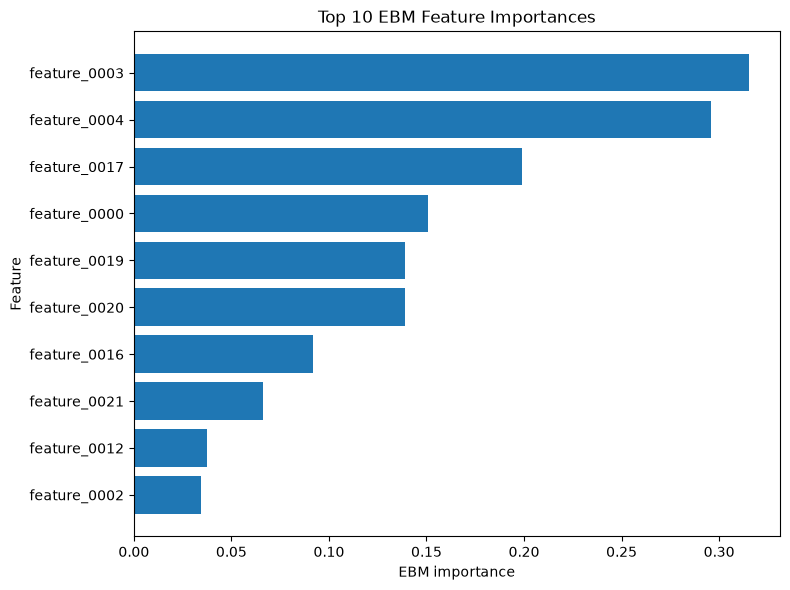

In [19]:
plt.figure(figsize=(8, 6))

plt.barh(
    ebm_importance_df["Feature"].head(10)[::-1],
    ebm_importance_df["Importance"].head(10)[::-1]
)

plt.xlabel("EBM importance")
plt.ylabel("Feature")
plt.title("Top 10 EBM Feature Importances")
plt.tight_layout()

plt.show()


In [20]:
feature_group_map = {}

for feature in feature_names:
    if "AGE" in feature:
        group = "AGE"
    elif "PTEDUCAT" in feature:
        group = "PTEDUCAT"
    elif "CDGLOBAL" in feature:
        group = "CDGLOBAL"
    elif "CDRSB" in feature:
        group = "CDRSB"
    elif "MMSCORE" in feature:
        group = "MMSCORE"
    elif "PTGENDER" in feature:
        group = "PTGENDER"
    elif "PTETHCAT" in feature:
        group = "PTETHCAT"
    elif "PTRACCAT" in feature:
        group = "PTRACCAT"
    elif "APOE" in feature:
        group = "APOE"
    else:
        group = "OTHER"

    feature_group_map[feature] = group

for feature, group in feature_group_map.items():
    print(f"{feature}  -->  {group}")

num__AGE  -->  AGE
num__PTEDUCAT  -->  PTEDUCAT
num__CDGLOBAL  -->  CDGLOBAL
num__CDRSB  -->  CDRSB
num__MMSCORE  -->  MMSCORE
cat__PTGENDER_Female  -->  PTGENDER
cat__PTGENDER_Male  -->  PTGENDER
cat__PTETHCAT_Hispanic or Latino  -->  PTETHCAT
cat__PTETHCAT_Not Hispanic or Latino  -->  PTETHCAT
cat__PTETHCAT_Unknown  -->  PTETHCAT
cat__PTRACCAT_American Indian or Alaskan Native  -->  PTRACCAT
cat__PTRACCAT_Asian  -->  PTRACCAT
cat__PTRACCAT_Black or African American  -->  PTRACCAT
cat__PTRACCAT_More than one race  -->  PTRACCAT
cat__PTRACCAT_Native Hawaiian or Other Pacific Islander  -->  PTRACCAT
cat__PTRACCAT_Unknown  -->  PTRACCAT
cat__PTRACCAT_White  -->  PTRACCAT
cat__APOE_ε2/ε3  -->  APOE
cat__APOE_ε2/ε4  -->  APOE
cat__APOE_ε3/ε3  -->  APOE
cat__APOE_ε3/ε4  -->  APOE
cat__APOE_ε4/ε4  -->  APOE


In [21]:
xgb_group_importance = {}

for group in primary_features:
    columns = [
        i for i, feature in enumerate(feature_names)
        if feature_group_map[feature] == group
    ]
    
    xgb_group_importance[group] = np.mean(
        np.abs(xgb_shap_values[:, columns])
    )

xgb_group_importance_df = pd.DataFrame({
    "Feature": list(xgb_group_importance.keys()),
    "Mean_Absolute_SHAP": list(xgb_group_importance.values())
})

xgb_group_importance_df = xgb_group_importance_df.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

print("XGBoost group-level SHAP importance:")
print(xgb_group_importance_df)

XGBoost group-level SHAP importance:
    Feature  Mean_Absolute_SHAP
0       AGE            0.771883
1     CDRSB            0.604142
2   MMSCORE            0.601648
3  PTEDUCAT            0.250165
4      APOE            0.140910
5  PTGENDER            0.039428
6  PTRACCAT            0.024245
7  CDGLOBAL            0.013136
8  PTETHCAT            0.005610


In [22]:
rf_group_importance = {}

for group in primary_features:
    columns = [
        i for i, feature in enumerate(feature_names)
        if feature_group_map[feature] == group
    ]
    
    rf_group_importance[group] = np.mean(
        np.abs(rf_shap_class1[:, columns])
    )

rf_group_importance_df = pd.DataFrame({
    "Feature": list(rf_group_importance.keys()),
    "Mean_Absolute_SHAP": list(rf_group_importance.values())
})

rf_group_importance_df = rf_group_importance_df.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

print("Random Forest group-level SHAP importance:")
print(rf_group_importance_df)


Random Forest group-level SHAP importance:
    Feature  Mean_Absolute_SHAP
0   MMSCORE            0.088569
1     CDRSB            0.088410
2       AGE            0.054141
3  PTEDUCAT            0.025181
4      APOE            0.018833
5  PTGENDER            0.009832
6  PTRACCAT            0.002237
7  CDGLOBAL            0.002153
8  PTETHCAT            0.000756


In [23]:
comparison = xgb_group_importance_df.merge(
    rf_group_importance_df,
    on="Feature",
    suffixes=("_XGBoost", "_RandomForest")
)

comparison

,Feature,Mean_Absolute_SHAP_XGBoost,Mean_Absolute_SHAP_RandomForest
0,AGE,0.771883,0.054141
1,CDRSB,0.604142,0.088410
2,MMSCORE,0.601648,0.088569
3,PTEDUCAT,0.250165,0.025181
4,APOE,0.140910,0.018833
5,PTGENDER,0.039428,0.009832
6,PTRACCAT,0.024245,0.002237
7,CDGLOBAL,0.013136,0.002153
8,PTETHCAT,0.005610,0.000756


In [24]:
from scipy.stats import spearmanr

spearman_corr, spearman_p = spearmanr(
    comparison["Mean_Absolute_SHAP_XGBoost"],
    comparison["Mean_Absolute_SHAP_RandomForest"]
)

print("Cross-model attribution consistency")
print("------------------------------------")
print("Spearman correlation:", spearman_corr)
print("p-value:", spearman_p)

Cross-model attribution consistency
------------------------------------
Spearman correlation: 0.9333333333333332
p-value: 0.00023589981215941651


In [25]:
top_k = 3

xgb_top3 = set(
    comparison.nlargest(top_k, "Mean_Absolute_SHAP_XGBoost")["Feature"]
)

rf_top3 = set(
    comparison.nlargest(top_k, "Mean_Absolute_SHAP_RandomForest")["Feature"]
)

intersection = xgb_top3.intersection(rf_top3)
union = xgb_top3.union(rf_top3)

jaccard_top3 = len(intersection) / len(union)

print("XGBoost Top-3:", sorted(xgb_top3))
print("Random Forest Top-3:", sorted(rf_top3))
print("Shared features:", sorted(intersection))
print("Top-3 Jaccard similarity:", jaccard_top3)

XGBoost Top-3: ['AGE', 'CDRSB', 'MMSCORE']
Random Forest Top-3: ['AGE', 'CDRSB', 'MMSCORE']
Shared features: ['AGE', 'CDRSB', 'MMSCORE']
Top-3 Jaccard similarity: 1.0


In [26]:
top_k = 5

xgb_top5 = set(
    comparison.nlargest(top_k, "Mean_Absolute_SHAP_XGBoost")["Feature"]
)

rf_top5 = set(
    comparison.nlargest(top_k, "Mean_Absolute_SHAP_RandomForest")["Feature"]
)

intersection = xgb_top5.intersection(rf_top5)
union = xgb_top5.union(rf_top5)

jaccard_top5 = len(intersection) / len(union)

print("XGBoost Top-5:", sorted(xgb_top5))
print("Random Forest Top-5:", sorted(rf_top5))
print("Shared features:", sorted(intersection))
print("Top-5 Jaccard similarity:", jaccard_top5)

XGBoost Top-5: ['AGE', 'APOE', 'CDRSB', 'MMSCORE', 'PTEDUCAT']
Random Forest Top-5: ['AGE', 'APOE', 'CDRSB', 'MMSCORE', 'PTEDUCAT']
Shared features: ['AGE', 'APOE', 'CDRSB', 'MMSCORE', 'PTEDUCAT']
Top-5 Jaccard similarity: 1.0


In [27]:
consistency_results = pd.DataFrame({
    "Metric": [
        "Spearman rank correlation",
        "Top-3 Jaccard similarity",
        "Top-5 Jaccard similarity"
    ],
    "Value": [
        spearman_corr,
        jaccard_top3,
        jaccard_top5
    ]
})

consistency_results.to_csv(
    "../results/cross_model_consistency.csv",
    index=False
)

print("Cross-model consistency results saved successfully.")
print(consistency_results)

Cross-model consistency results saved successfully.
                      Metric     Value
0  Spearman rank correlation  0.933333
1   Top-3 Jaccard similarity  1.000000
2   Top-5 Jaccard similarity  1.000000


In [28]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-fold stratified cross-validation created.")
print("Number of folds:", cv.get_n_splits())

5-fold stratified cross-validation created.
Number of folds: 5


In [29]:
stability_results = []

print("Stability analysis initialized.")
print("Ready for 5-fold attribution analysis.")


Stability analysis initialized.
Ready for 5-fold attribution analysis.


In [30]:
folds = list(cv.split(X, y))

print("Number of folds:", len(folds))

for fold_number, (train_idx, val_idx) in enumerate(folds, start=1):
    print(
        f"Fold {fold_number}: "
        f"training = {len(train_idx)}, "
        f"validation = {len(val_idx)}"
    )

Number of folds: 5
Fold 1: training = 797, validation = 200
Fold 2: training = 797, validation = 200
Fold 3: training = 798, validation = 199
Fold 4: training = 798, validation = 199
Fold 5: training = 798, validation = 199


In [31]:
for fold_number, (train_idx, val_idx) in enumerate(folds, start=1):
    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]

    print(f"\nFold {fold_number}")
    print("Training:", y_train_fold.value_counts().to_dict())
    print("Validation:", y_val_fold.value_counts().to_dict())


Fold 1
Training: {0: 702, 1: 95}
Validation: {0: 176, 1: 24}

Fold 2
Training: {0: 702, 1: 95}
Validation: {0: 176, 1: 24}

Fold 3
Training: {0: 703, 1: 95}
Validation: {0: 175, 1: 24}

Fold 4
Training: {0: 703, 1: 95}
Validation: {0: 175, 1: 24}

Fold 5
Training: {0: 702, 1: 96}
Validation: {0: 176, 1: 23}


In [32]:
xgb_fold_importance = []

for fold_number, (train_idx, val_idx) in enumerate(folds, start=1):

    X_train_fold = X.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]

    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]

    # Fit preprocessing only on the training portion
    fold_preprocessor = ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ))
        ]), categorical_features)
    ])

    X_train_fold_processed = fold_preprocessor.fit_transform(X_train_fold)
    X_val_fold_processed = fold_preprocessor.transform(X_val_fold)

    fold_feature_names = fold_preprocessor.get_feature_names_out()

    # Train XGBoost
    fold_model = XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=(
            len(y_train_fold[y_train_fold == 0]) /
            len(y_train_fold[y_train_fold == 1])
        ),
        eval_metric="logloss",
        random_state=42
    )

    fold_model.fit(
        X_train_fold_processed,
        y_train_fold
    )

    # Calculate SHAP values
    fold_explainer = shap.TreeExplainer(fold_model)

    fold_shap_values = fold_explainer.shap_values(
        X_val_fold_processed
    )

    # Group one-hot features back to original features
    fold_group_values = {}

    for group in primary_features:

        columns = [
            i for i, feature in enumerate(fold_feature_names)
            if (
                (group == "AGE" and "AGE" in feature) or
                (group == "PTEDUCAT" and "PTEDUCAT" in feature) or
                (group == "CDGLOBAL" and "CDGLOBAL" in feature) or
                (group == "CDRSB" and "CDRSB" in feature) or
                (group == "MMSCORE" and "MMSCORE" in feature) or
                (group == "PTGENDER" and "PTGENDER" in feature) or
                (group == "PTETHCAT" and "PTETHCAT" in feature) or
                (group == "PTRACCAT" and "PTRACCAT" in feature) or
                (group == "APOE" and "APOE" in feature)
            )
        ]

        fold_group_values[group] = np.mean(
            np.abs(fold_shap_values[:, columns])
        )

    fold_result = {
        "Fold": fold_number,
        **fold_group_values
    }

    xgb_fold_importance.append(fold_result)

    print(f"Fold {fold_number} completed.")

xgb_stability_df = pd.DataFrame(xgb_fold_importance)

print("\nXGBoost fold-level attribution results:")
print(xgb_stability_df)

Fold 1 completed.
Fold 2 completed.
Fold 3 completed.
Fold 4 completed.
Fold 5 completed.

XGBoost fold-level attribution results:
   Fold       AGE  PTGENDER  PTEDUCAT  PTETHCAT  PTRACCAT      APOE  CDGLOBAL  \
0     1  0.722324  0.050552  0.255691  0.016643  0.026975  0.141075  0.015749   
1     2  0.750933  0.034682  0.283872  0.008587  0.017366  0.137776  0.032488   
2     3  0.633340  0.087500  0.237215  0.017907  0.018205  0.150572  0.014586   
3     4  0.762241  0.063489  0.281231  0.009613  0.024601  0.110411  0.016806   
4     5  0.674876  0.032359  0.265270  0.011099  0.035925  0.124836  0.015317   

      CDRSB   MMSCORE  
0  0.749981  0.696027  
1  0.650825  0.691167  
2  0.581564  0.565715  
3  0.609562  0.557866  
4  0.461277  0.729447  


In [33]:
xgb_stability_summary = xgb_stability_df.drop(
    columns="Fold"
).agg(["mean", "std"]).T

xgb_stability_summary["CV"] = (
    xgb_stability_summary["std"] /
    xgb_stability_summary["mean"]
)

xgb_stability_summary = xgb_stability_summary.sort_values(
    "mean",
    ascending=False
)

print("XGBoost attribution stability summary:")
print(xgb_stability_summary)

XGBoost attribution stability summary:
              mean       std        CV
AGE       0.708743  0.053989  0.076175
MMSCORE   0.648044  0.080154  0.123686
CDRSB     0.610642  0.105103  0.172119
PTEDUCAT  0.264656  0.019221  0.072625
APOE      0.132934  0.015602  0.117365
PTGENDER  0.053716  0.022723  0.423013
PTRACCAT  0.024614  0.007535  0.306137
CDGLOBAL  0.018989  0.007589  0.399634
PTETHCAT  0.012770  0.004232  0.331443


In [34]:
rf_fold_importance = []

for fold_number, (train_idx, val_idx) in enumerate(folds, start=1):

    X_train_fold = X.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]

    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]

    # Fit preprocessing only on the training portion
    fold_preprocessor = ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ))
        ]), categorical_features)
    ])

    X_train_fold_processed = fold_preprocessor.fit_transform(X_train_fold)
    X_val_fold_processed = fold_preprocessor.transform(X_val_fold)

    fold_feature_names = fold_preprocessor.get_feature_names_out()

    # Train Random Forest
    fold_model = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    fold_model.fit(
        X_train_fold_processed,
        y_train_fold
    )

    # Calculate SHAP values
    fold_explainer = shap.TreeExplainer(fold_model)
    fold_shap_values = fold_explainer.shap_values(
        X_val_fold_processed
    )

    # Select class 1 = AD conversion
    if isinstance(fold_shap_values, list):
        fold_shap_class1 = fold_shap_values[1]
    else:
        fold_shap_class1 = fold_shap_values[:, :, 1]

    # Group one-hot features
    fold_group_values = {}

    for group in primary_features:

        columns = [
            i for i, feature in enumerate(fold_feature_names)
            if (
                (group == "AGE" and "AGE" in feature) or
                (group == "PTEDUCAT" and "PTEDUCAT" in feature) or
                (group == "CDGLOBAL" and "CDGLOBAL" in feature) or
                (group == "CDRSB" and "CDRSB" in feature) or
                (group == "MMSCORE" and "MMSCORE" in feature) or
                (group == "PTGENDER" and "PTGENDER" in feature) or
                (group == "PTETHCAT" and "PTETHCAT" in feature) or
                (group == "PTRACCAT" and "PTRACCAT" in feature) or
                (group == "APOE" and "APOE" in feature)
            )
        ]

        fold_group_values[group] = np.mean(
            np.abs(fold_shap_class1[:, columns])
        )

    fold_result = {
        "Fold": fold_number,
        **fold_group_values
    }

    rf_fold_importance.append(fold_result)

    print(f"Fold {fold_number} completed.")

rf_stability_df = pd.DataFrame(rf_fold_importance)

print("\nRandom Forest fold-level attribution results:")
print(rf_stability_df)

Fold 1 completed.
Fold 2 completed.
Fold 3 completed.
Fold 4 completed.
Fold 5 completed.

Random Forest fold-level attribution results:
   Fold       AGE  PTGENDER  PTEDUCAT  PTETHCAT  PTRACCAT      APOE  CDGLOBAL  \
0     1  0.054670  0.008860  0.022387  0.001135  0.002875  0.021112  0.002065   
1     2  0.051157  0.007159  0.028241  0.000614  0.001998  0.018095  0.002640   
2     3  0.056666  0.012112  0.021863  0.001339  0.002043  0.020434  0.001489   
3     4  0.060647  0.008704  0.024958  0.001319  0.003038  0.016444  0.003232   
4     5  0.043519  0.009110  0.025666  0.000837  0.004011  0.017444  0.002747   

      CDRSB   MMSCORE  
0  0.103262  0.086779  
1  0.101848  0.104144  
2  0.093367  0.086258  
3  0.090972  0.092518  
4  0.074149  0.100399  


In [35]:
rf_stability_summary = rf_stability_df.drop(
    columns="Fold"
).agg(["mean", "std"]).T

rf_stability_summary["CV"] = (
    rf_stability_summary["std"] /
    rf_stability_summary["mean"]
)

rf_stability_summary = rf_stability_summary.sort_values(
    "mean",
    ascending=False
)

print("Random Forest attribution stability summary:")
print(rf_stability_summary)

Random Forest attribution stability summary:
              mean       std        CV
MMSCORE   0.094020  0.008033  0.085441
CDRSB     0.092720  0.011649  0.125638
AGE       0.053332  0.006470  0.121312
PTEDUCAT  0.024623  0.002593  0.105324
APOE      0.018706  0.001991  0.106430
PTGENDER  0.009189  0.001804  0.196285
PTRACCAT  0.002793  0.000828  0.296616
CDGLOBAL  0.002435  0.000672  0.276011
PTETHCAT  0.001049  0.000316  0.301279


In [37]:
stability_comparison = pd.DataFrame({
    "XGBoost_Mean": xgb_stability_summary["mean"],
    "XGBoost_CV": xgb_stability_summary["CV"],
    "RandomForest_Mean": rf_stability_summary["mean"],
    "RandomForest_CV": rf_stability_summary["CV"]
})

stability_comparison = stability_comparison.loc[
    primary_features
]

print("Cross-model stability comparison:")
print(stability_comparison)

Cross-model stability comparison:
          XGBoost_Mean  XGBoost_CV  RandomForest_Mean  RandomForest_CV
AGE           0.708743    0.076175           0.053332         0.121312
PTGENDER      0.053716    0.423013           0.009189         0.196285
PTEDUCAT      0.264656    0.072625           0.024623         0.105324
PTETHCAT      0.012770    0.331443           0.001049         0.301279
PTRACCAT      0.024614    0.306137           0.002793         0.296616
APOE          0.132934    0.117365           0.018706         0.106430
CDGLOBAL      0.018989    0.399634           0.002435         0.276011
CDRSB         0.610642    0.172119           0.092720         0.125638
MMSCORE       0.648044    0.123686           0.094020         0.085441


In [38]:
from scipy.stats import spearmanr

fold_mean_spearman, fold_mean_p = spearmanr(
    stability_comparison["XGBoost_Mean"],
    stability_comparison["RandomForest_Mean"]
)

print("Spearman correlation of 5-fold mean attributions:")
print("rho =", fold_mean_spearman)
print("p-value =", fold_mean_p)

Spearman correlation of 5-fold mean attributions:
rho = 0.9500000000000001
p-value = 8.762523965086185e-05


In [39]:
xgb_fold_rank_corr = xgb_stability_df.drop(
    columns="Fold"
).T.corr(method="spearman")

xgb_mean_rank_corr = xgb_fold_rank_corr.values[
    np.triu_indices_from(xgb_fold_rank_corr, k=1)
].mean()

print("XGBoost mean pairwise fold-rank Spearman correlation:")
print(xgb_mean_rank_corr)

XGBoost mean pairwise fold-rank Spearman correlation:
0.9416666666666667


In [40]:
rf_fold_rank_corr = rf_stability_df.drop(
    columns="Fold"
).T.corr(method="spearman")

rf_mean_rank_corr = rf_fold_rank_corr.values[
    np.triu_indices_from(rf_fold_rank_corr, k=1)
].mean()

print("Random Forest mean pairwise fold-rank Spearman correlation:")
print(rf_mean_rank_corr)

Random Forest mean pairwise fold-rank Spearman correlation:
0.9799999999999999


In [41]:
from interpret.glassbox import ExplainableBoostingClassifier

ebm_fold_importance = []

for fold_number, (train_idx, val_idx) in enumerate(folds, start=1):

    X_train_fold = X.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]

    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]

    fold_preprocessor = ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ))
        ]), categorical_features)
    ])

    X_train_fold_processed = fold_preprocessor.fit_transform(X_train_fold)
    X_val_fold_processed = fold_preprocessor.transform(X_val_fold)

    fold_feature_names = fold_preprocessor.get_feature_names_out()

    fold_model = ExplainableBoostingClassifier(
        interactions=0,
        random_state=42
    )

    fold_model.fit(
        X_train_fold_processed,
        y_train_fold
    )

    fold_global = fold_model.explain_global()
    fold_data = fold_global.data()

    fold_names = fold_data["names"]
    fold_scores = fold_data["scores"]

    fold_group_values = {}

    for group in primary_features:

        matching_scores = []

        for feature_name, score in zip(
            fold_names,
            fold_scores
        ):

            if (
                (group == "AGE" and "AGE" in feature_name) or
                (group == "PTEDUCAT" and "PTEDUCAT" in feature_name) or
                (group == "CDGLOBAL" and "CDGLOBAL" in feature_name) or
                (group == "CDRSB" and "CDRSB" in feature_name) or
                (group == "MMSCORE" and "MMSCORE" in feature_name) or
                (group == "PTGENDER" and "PTGENDER" in feature_name) or
                (group == "PTETHCAT" and "PTETHCAT" in feature_name) or
                (group == "PTRACCAT" and "PTRACCAT" in feature_name) or
                (group == "APOE" and "APOE" in feature_name)
            ):
                matching_scores.append(abs(score))

        fold_group_values[group] = np.mean(matching_scores)

    fold_result = {
        "Fold": fold_number,
        **fold_group_values
    }

    ebm_fold_importance.append(fold_result)

    print(f"Fold {fold_number} completed.")

ebm_stability_df = pd.DataFrame(ebm_fold_importance)

print("\nEBM fold-level attribution results:")
print(ebm_stability_df)

c:\Users\anura\.conda\envs\mci_ad_xai\Lib\site-packages\numpy\_core\fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\anura\.conda\envs\mci_ad_xai\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Fold 1 completed.


c:\Users\anura\.conda\envs\mci_ad_xai\Lib\site-packages\numpy\_core\fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\anura\.conda\envs\mci_ad_xai\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Fold 2 completed.


c:\Users\anura\.conda\envs\mci_ad_xai\Lib\site-packages\numpy\_core\fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\anura\.conda\envs\mci_ad_xai\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Fold 3 completed.


c:\Users\anura\.conda\envs\mci_ad_xai\Lib\site-packages\numpy\_core\fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\anura\.conda\envs\mci_ad_xai\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Fold 4 completed.
Fold 5 completed.

EBM fold-level attribution results:
   Fold  AGE  PTGENDER  PTEDUCAT  PTETHCAT  PTRACCAT  APOE  CDGLOBAL  CDRSB  \
0     1  NaN       NaN       NaN       NaN       NaN   NaN       NaN    NaN   
1     2  NaN       NaN       NaN       NaN       NaN   NaN       NaN    NaN   
2     3  NaN       NaN       NaN       NaN       NaN   NaN       NaN    NaN   
3     4  NaN       NaN       NaN       NaN       NaN   NaN       NaN    NaN   
4     5  NaN       NaN       NaN       NaN       NaN   NaN       NaN    NaN   

   MMSCORE  
0      NaN  
1      NaN  
2      NaN  
3      NaN  
4      NaN  


c:\Users\anura\.conda\envs\mci_ad_xai\Lib\site-packages\numpy\_core\fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\anura\.conda\envs\mci_ad_xai\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [42]:
print("EBM feature names from Fold 1:")
print(ebm_fold_importance)


EBM feature names from Fold 1:
[{'Fold': 1, 'AGE': np.float64(nan), 'PTGENDER': np.float64(nan), 'PTEDUCAT': np.float64(nan), 'PTETHCAT': np.float64(nan), 'PTRACCAT': np.float64(nan), 'APOE': np.float64(nan), 'CDGLOBAL': np.float64(nan), 'CDRSB': np.float64(nan), 'MMSCORE': np.float64(nan)}, {'Fold': 2, 'AGE': np.float64(nan), 'PTGENDER': np.float64(nan), 'PTEDUCAT': np.float64(nan), 'PTETHCAT': np.float64(nan), 'PTRACCAT': np.float64(nan), 'APOE': np.float64(nan), 'CDGLOBAL': np.float64(nan), 'CDRSB': np.float64(nan), 'MMSCORE': np.float64(nan)}, {'Fold': 3, 'AGE': np.float64(nan), 'PTGENDER': np.float64(nan), 'PTEDUCAT': np.float64(nan), 'PTETHCAT': np.float64(nan), 'PTRACCAT': np.float64(nan), 'APOE': np.float64(nan), 'CDGLOBAL': np.float64(nan), 'CDRSB': np.float64(nan), 'MMSCORE': np.float64(nan)}, {'Fold': 4, 'AGE': np.float64(nan), 'PTGENDER': np.float64(nan), 'PTEDUCAT': np.float64(nan), 'PTETHCAT': np.float64(nan), 'PTRACCAT': np.float64(nan), 'APOE': np.float64(nan), 'CDGLOBA

In [43]:
ebm_global_check = fold_model.explain_global()
ebm_data_check = ebm_global_check.data()

print("Number of EBM features:", len(ebm_data_check["names"]))
print("\nEBM feature names:")
for name in ebm_data_check["names"]:
    print(name)

Number of EBM features: 22

EBM feature names:
feature_0000
feature_0001
feature_0002
feature_0003
feature_0004
feature_0005
feature_0006
feature_0007
feature_0008
feature_0009
feature_0010
feature_0011
feature_0012
feature_0013
feature_0014
feature_0015
feature_0016
feature_0017
feature_0018
feature_0019
feature_0020
feature_0021


In [44]:
ebm_feature_names = ebm_data_check["names"]

encoded_feature_names = fold_preprocessor.get_feature_names_out()

print("EBM features:", len(ebm_feature_names))
print("Encoded features:", len(encoded_feature_names))

print("\nMapping:")
for ebm_name, encoded_name in zip(
    ebm_feature_names,
    encoded_feature_names
):
    print(ebm_name, "->", encoded_name)

EBM features: 22
Encoded features: 22

Mapping:
feature_0000 -> num__AGE
feature_0001 -> num__PTEDUCAT
feature_0002 -> num__CDGLOBAL
feature_0003 -> num__CDRSB
feature_0004 -> num__MMSCORE
feature_0005 -> cat__PTGENDER_Female
feature_0006 -> cat__PTGENDER_Male
feature_0007 -> cat__PTETHCAT_Hispanic or Latino
feature_0008 -> cat__PTETHCAT_Not Hispanic or Latino
feature_0009 -> cat__PTETHCAT_Unknown
feature_0010 -> cat__PTRACCAT_American Indian or Alaskan Native
feature_0011 -> cat__PTRACCAT_Asian
feature_0012 -> cat__PTRACCAT_Black or African American
feature_0013 -> cat__PTRACCAT_More than one race
feature_0014 -> cat__PTRACCAT_Native Hawaiian or Other Pacific Islander
feature_0015 -> cat__PTRACCAT_Unknown
feature_0016 -> cat__PTRACCAT_White
feature_0017 -> cat__APOE_ε2/ε3
feature_0018 -> cat__APOE_ε2/ε4
feature_0019 -> cat__APOE_ε3/ε3
feature_0020 -> cat__APOE_ε3/ε4
feature_0021 -> cat__APOE_ε4/ε4


In [45]:
ebm_fold_importance = []

for fold_number, (train_idx, val_idx) in enumerate(folds, start=1):

    X_train_fold = X.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]

    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]

    fold_preprocessor = ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ))
        ]), categorical_features)
    ])

    X_train_fold_processed = fold_preprocessor.fit_transform(X_train_fold)
    X_val_fold_processed = fold_preprocessor.transform(X_val_fold)

    fold_model = ExplainableBoostingClassifier(
        interactions=0,
        random_state=42
    )

    fold_model.fit(
        X_train_fold_processed,
        y_train_fold
    )

    fold_global = fold_model.explain_global()
    fold_data = fold_global.data()

    ebm_feature_names = fold_data["names"]
    ebm_scores = fold_data["scores"]

    encoded_feature_names = fold_preprocessor.get_feature_names_out()

    feature_to_group = {}

    for ebm_name, encoded_name in zip(
        ebm_feature_names,
        encoded_feature_names
    ):
        if "AGE" in encoded_name:
            group = "AGE"
        elif "PTEDUCAT" in encoded_name:
            group = "PTEDUCAT"
        elif "CDGLOBAL" in encoded_name:
            group = "CDGLOBAL"
        elif "CDRSB" in encoded_name:
            group = "CDRSB"
        elif "MMSCORE" in encoded_name:
            group = "MMSCORE"
        elif "PTGENDER" in encoded_name:
            group = "PTGENDER"
        elif "PTETHCAT" in encoded_name:
            group = "PTETHCAT"
        elif "PTRACCAT" in encoded_name:
            group = "PTRACCAT"
        elif "APOE" in encoded_name:
            group = "APOE"
        else:
            group = "OTHER"

        feature_to_group[ebm_name] = group

    fold_group_values = {}

    for group in primary_features:

        group_scores = [
            abs(score)
            for feature_name, score in zip(
                ebm_feature_names,
                ebm_scores
            )
            if feature_to_group[feature_name] == group
        ]

        fold_group_values[group] = np.mean(group_scores)

    fold_result = {
        "Fold": fold_number,
        **fold_group_values
    }

    ebm_fold_importance.append(fold_result)

    print(f"Fold {fold_number} completed.")

ebm_stability_df = pd.DataFrame(
    ebm_fold_importance
)

print("\nCorrected EBM fold-level attribution results:")
print(ebm_stability_df)

Fold 1 completed.
Fold 2 completed.
Fold 3 completed.
Fold 4 completed.
Fold 5 completed.

Corrected EBM fold-level attribution results:
   Fold       AGE  PTGENDER  PTEDUCAT  PTETHCAT  PTRACCAT      APOE  CDGLOBAL  \
0     1  0.095121  0.019710  0.016642  0.011233  0.027856  0.107854  0.032549   
1     2  0.120355  0.018537  0.063276  0.004704  0.021708  0.089434  0.031905   
2     3  0.116050  0.035408  0.032389  0.011524  0.024897  0.099931  0.032907   
3     4  0.173101  0.020189  0.020172  0.009588  0.023531  0.078910  0.028286   
4     5  0.109517  0.031537  0.029323  0.006105  0.025998  0.081378  0.021528   

      CDRSB   MMSCORE  
0  0.320212  0.251123  
1  0.263564  0.317321  
2  0.284852  0.223919  
3  0.275104  0.276046  
4  0.189823  0.247094  


In [46]:
ebm_stability_summary = ebm_stability_df.drop(
    columns="Fold"
).agg(["mean", "std"]).T

ebm_stability_summary["CV"] = (
    ebm_stability_summary["std"] /
    ebm_stability_summary["mean"]
)

ebm_stability_summary = ebm_stability_summary.sort_values(
    "mean",
    ascending=False
)

print("EBM attribution stability summary:")
print(ebm_stability_summary)

EBM attribution stability summary:
              mean       std        CV
CDRSB     0.266711  0.047916  0.179654
MMSCORE   0.263101  0.035505  0.134947
AGE       0.122829  0.029683  0.241661
APOE      0.091501  0.012286  0.134269
PTEDUCAT  0.032361  0.018443  0.569934
CDGLOBAL  0.029435  0.004788  0.162661
PTGENDER  0.025076  0.007809  0.311409
PTRACCAT  0.024798  0.002343  0.094472
PTETHCAT  0.008631  0.003076  0.356431


In [47]:
ebm_fold_rank_corr = ebm_stability_df.drop(
    columns="Fold"
).T.corr(method="spearman")

ebm_mean_rank_corr = ebm_fold_rank_corr.values[
    np.triu_indices_from(ebm_fold_rank_corr, k=1)
].mean()

print("EBM mean pairwise fold-rank Spearman correlation:")

print(ebm_mean_rank_corr)

EBM mean pairwise fold-rank Spearman correlation:
0.8883333333333333


In [48]:
model_stability_results = pd.DataFrame({
    "Model": [
        "XGBoost",
        "Random Forest",
        "EBM"
    ],
    "Mean_Pairwise_Fold_Rank_Spearman": [
        xgb_mean_rank_corr,
        rf_mean_rank_corr,
        ebm_mean_rank_corr
    ]
})

model_stability_results.to_csv(
    "../results/model_stability_summary.csv",
    index=False
)

print("Saved model stability summary:")
print(model_stability_results)


Saved model stability summary:
           Model  Mean_Pairwise_Fold_Rank_Spearman
0        XGBoost                          0.941667
1  Random Forest                          0.980000
2            EBM                          0.888333


In [49]:
three_model_mean_attribution = pd.DataFrame({
    "Feature": primary_features,
    "XGBoost": [
        xgb_stability_summary.loc[f, "mean"]
        for f in primary_features
    ],
    "RandomForest": [
        rf_stability_summary.loc[f, "mean"]
        for f in primary_features
    ],
    "EBM": [
        ebm_stability_summary.loc[f, "mean"]
        for f in primary_features
    ]
})

print("Three-model mean attribution:")
print(three_model_mean_attribution)

Three-model mean attribution:
    Feature   XGBoost  RandomForest       EBM
0       AGE  0.708743      0.053332  0.122829
1  PTGENDER  0.053716      0.009189  0.025076
2  PTEDUCAT  0.264656      0.024623  0.032361
3  PTETHCAT  0.012770      0.001049  0.008631
4  PTRACCAT  0.024614      0.002793  0.024798
5      APOE  0.132934      0.018706  0.091501
6  CDGLOBAL  0.018989      0.002435  0.029435
7     CDRSB  0.610642      0.092720  0.266711
8   MMSCORE  0.648044      0.094020  0.263101


In [50]:
three_model_ranks = three_model_mean_attribution.copy()

three_model_ranks["XGBoost_Rank"] = (
    three_model_ranks["XGBoost"]
    .rank(ascending=False, method="min")
)

three_model_ranks["RandomForest_Rank"] = (
    three_model_ranks["RandomForest"]
    .rank(ascending=False, method="min")
)

three_model_ranks["EBM_Rank"] = (
    three_model_ranks["EBM"]
    .rank(ascending=False, method="min")
)

three_model_ranks = three_model_ranks.sort_values(
    "XGBoost_Rank"
)

print("Three-model feature rankings:")
print(
    three_model_ranks[
        [
            "Feature",
            "XGBoost_Rank",
            "RandomForest_Rank",
            "EBM_Rank"
        ]
    ]
)

Three-model feature rankings:
    Feature  XGBoost_Rank  RandomForest_Rank  EBM_Rank
0       AGE           1.0                3.0       3.0
8   MMSCORE           2.0                1.0       2.0
7     CDRSB           3.0                2.0       1.0
2  PTEDUCAT           4.0                4.0       5.0
5      APOE           5.0                5.0       4.0
1  PTGENDER           6.0                6.0       7.0
4  PTRACCAT           7.0                7.0       8.0
6  CDGLOBAL           8.0                8.0       6.0
3  PTETHCAT           9.0                9.0       9.0


In [51]:
rank_columns = [
    "XGBoost_Rank",
    "RandomForest_Rank",
    "EBM_Rank"
]

three_model_rank_corr = three_model_ranks[
    rank_columns
].corr(method="spearman")

print("Three-model feature-rank Spearman correlation:")
print(three_model_rank_corr)

Three-model feature-rank Spearman correlation:
                   XGBoost_Rank  RandomForest_Rank  EBM_Rank
XGBoost_Rank           1.000000           0.950000  0.866667
RandomForest_Rank      0.950000           1.000000  0.916667
EBM_Rank               0.866667           0.916667  1.000000


In [52]:
pairwise_consistency = pd.DataFrame({
    "Model_1": [
        "XGBoost",
        "XGBoost",
        "Random Forest"
    ],
    "Model_2": [
        "Random Forest",
        "EBM",
        "EBM"
    ],
    "Spearman_Rank_Correlation": [
        three_model_rank_corr.loc[
            "XGBoost_Rank", "RandomForest_Rank"
        ],
        three_model_rank_corr.loc[
            "XGBoost_Rank", "EBM_Rank"
        ],
        three_model_rank_corr.loc[
            "RandomForest_Rank", "EBM_Rank"
        ]
    ]
})

pairwise_consistency.to_csv(
    "../results/three_model_pairwise_consistency.csv",
    index=False
)

print("Saved three-model pairwise consistency:")
print(pairwise_consistency)

Saved three-model pairwise consistency:
         Model_1        Model_2  Spearman_Rank_Correlation
0        XGBoost  Random Forest                   0.950000
1        XGBoost            EBM                   0.866667
2  Random Forest            EBM                   0.916667


In [53]:
top_k_results = []

for k in [3, 5]:

    xgb_top = set(
        three_model_ranks
        .nsmallest(k, "XGBoost_Rank")["Feature"]
    )

    rf_top = set(
        three_model_ranks
        .nsmallest(k, "RandomForest_Rank")["Feature"]
    )

    ebm_top = set(
        three_model_ranks
        .nsmallest(k, "EBM_Rank")["Feature"]
    )

    all_three = xgb_top & rf_top & ebm_top
    union_all = xgb_top | rf_top | ebm_top

    jaccard_all = (
        len(all_three) / len(union_all)
    )

    top_k_results.append({
        "Top_K": k,
        "XGBoost_Top": ", ".join(sorted(xgb_top)),
        "RandomForest_Top": ", ".join(sorted(rf_top)),
        "EBM_Top": ", ".join(sorted(ebm_top)),
        "Shared_All_Three": ", ".join(sorted(all_three)),
        "Three_Model_Jaccard": jaccard_all
    })

top_k_consistency = pd.DataFrame(top_k_results)

print("Top-k three-model consistency:")
print(top_k_consistency)

Top-k three-model consistency:
   Top_K                          XGBoost_Top  \
0      3                  AGE, CDRSB, MMSCORE   
1      5  AGE, APOE, CDRSB, MMSCORE, PTEDUCAT   

                      RandomForest_Top                              EBM_Top  \
0                  AGE, CDRSB, MMSCORE                  AGE, CDRSB, MMSCORE   
1  AGE, APOE, CDRSB, MMSCORE, PTEDUCAT  AGE, APOE, CDRSB, MMSCORE, PTEDUCAT   

                      Shared_All_Three  Three_Model_Jaccard  
0                  AGE, CDRSB, MMSCORE                  1.0  
1  AGE, APOE, CDRSB, MMSCORE, PTEDUCAT                  1.0  


In [54]:
top_k_consistency.to_csv(
    "../results/three_model_top_k_consistency.csv",
    index=False
)

print("Saved Top-k consistency results:")
print(top_k_consistency)

Saved Top-k consistency results:
   Top_K                          XGBoost_Top  \
0      3                  AGE, CDRSB, MMSCORE   
1      5  AGE, APOE, CDRSB, MMSCORE, PTEDUCAT   

                      RandomForest_Top                              EBM_Top  \
0                  AGE, CDRSB, MMSCORE                  AGE, CDRSB, MMSCORE   
1  AGE, APOE, CDRSB, MMSCORE, PTEDUCAT  AGE, APOE, CDRSB, MMSCORE, PTEDUCAT   

                      Shared_All_Three  Three_Model_Jaccard  
0                  AGE, CDRSB, MMSCORE                  1.0  
1  AGE, APOE, CDRSB, MMSCORE, PTEDUCAT                  1.0  


In [55]:
xai_summary = pd.DataFrame({
    "Model": [
        "XGBoost",
        "Random Forest",
        "EBM"
    ],
    "Within_Model_Rank_Stability": [
        xgb_mean_rank_corr,
        rf_mean_rank_corr,
        ebm_mean_rank_corr
    ]
})

print("Consolidated model stability summary:")
print(xai_summary)

xai_summary.to_csv(
    "../results/xai_model_stability_summary.csv",
    index=False
)

Consolidated model stability summary:
           Model  Within_Model_Rank_Stability
0        XGBoost                     0.941667
1  Random Forest                     0.980000
2            EBM                     0.888333


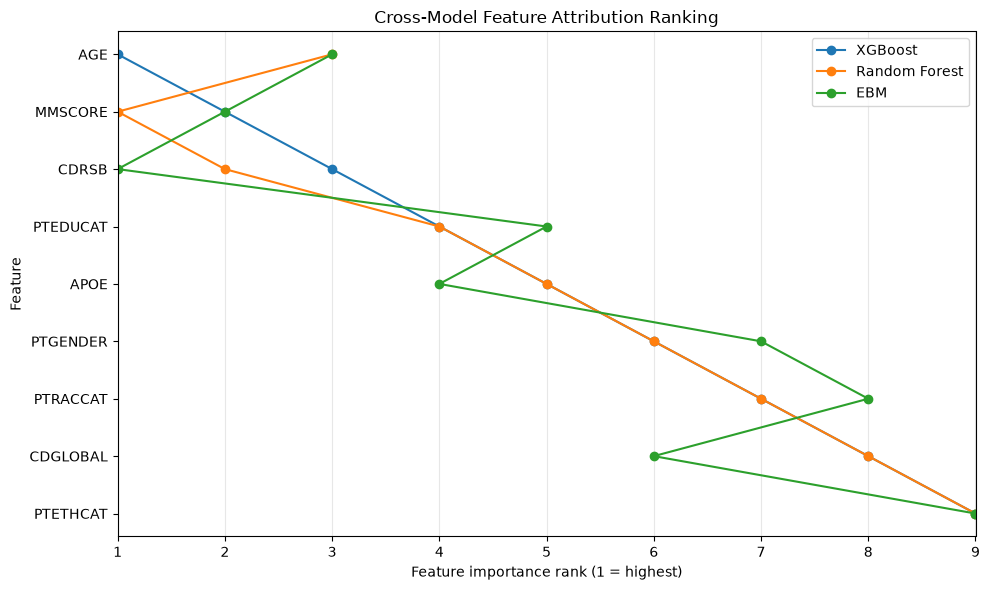

In [59]:
fig, ax = plt.subplots(figsize=(10, 6))

plot_order = three_model_ranks.sort_values(
    "XGBoost_Rank",
    ascending=True
)

features = plot_order["Feature"].tolist()

ax.plot(
    plot_order["XGBoost_Rank"],
    features,
    marker="o",
    label="XGBoost"
)

ax.plot(
    plot_order["RandomForest_Rank"],
    features,
    marker="o",
    label="Random Forest"
)

ax.plot(
    plot_order["EBM_Rank"],
    features,
    marker="o",
    label="EBM"
)

ax.set_xlabel("Feature importance rank (1 = highest)")
ax.set_ylabel("Feature")
ax.set_title("Cross-Model Feature Attribution Ranking")

ax.set_xlim(1, 9)
ax.set_xticks(range(1, 10))

# Put the highest-ranked feature at the top
ax.invert_yaxis()

ax.grid(axis="x", alpha=0.3)
ax.legend()

plt.tight_layout()

plt.savefig(
    "../results/three_model_feature_ranking_final.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [60]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

performance_results = []

for fold_number, (train_idx, val_idx) in enumerate(folds, start=1):

    X_train_fold = X.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]

    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]

    fold_preprocessor = ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ))
        ]), categorical_features)
    ])

    X_train_processed = fold_preprocessor.fit_transform(X_train_fold)
    X_val_processed = fold_preprocessor.transform(X_val_fold)

    # -------------------------
    # XGBoost
    # -------------------------
    xgb_fold = XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=(
            len(y_train_fold[y_train_fold == 0]) /
            len(y_train_fold[y_train_fold == 1])
        ),
        eval_metric="logloss",
        random_state=42
    )

    xgb_fold.fit(X_train_processed, y_train_fold)

    xgb_prob = xgb_fold.predict_proba(
        X_val_processed
    )[:, 1]

    xgb_pred = (xgb_prob >= 0.5).astype(int)

    performance_results.append({
        "Fold": fold_number,
        "Model": "XGBoost",
        "Accuracy": accuracy_score(y_val_fold, xgb_pred),
        "Balanced_Accuracy": balanced_accuracy_score(
            y_val_fold, xgb_pred
        ),
        "Precision": precision_score(
            y_val_fold, xgb_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_val_fold, xgb_pred, zero_division=0
        ),
        "F1": f1_score(
            y_val_fold, xgb_pred, zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_val_fold, xgb_prob
        ),
        "PR_AUC": average_precision_score(
            y_val_fold, xgb_prob
        )
    })

    # -------------------------
    # Random Forest
    # -------------------------
    rf_fold = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    rf_fold.fit(X_train_processed, y_train_fold)

    rf_prob = rf_fold.predict_proba(
        X_val_processed
    )[:, 1]

    rf_pred = (rf_prob >= 0.5).astype(int)

    performance_results.append({
        "Fold": fold_number,
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_val_fold, rf_pred),
        "Balanced_Accuracy": balanced_accuracy_score(
            y_val_fold, rf_pred
        ),
        "Precision": precision_score(
            y_val_fold, rf_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_val_fold, rf_pred, zero_division=0
        ),
        "F1": f1_score(
            y_val_fold, rf_pred, zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_val_fold, rf_prob
        ),
        "PR_AUC": average_precision_score(
            y_val_fold, rf_prob
        )
    })

    # -------------------------
    # EBM
    # -------------------------
    ebm_fold = ExplainableBoostingClassifier(
        interactions=0,
        random_state=42
    )

    ebm_fold.fit(X_train_processed, y_train_fold)

    ebm_prob = ebm_fold.predict_proba(
        X_val_processed
    )[:, 1]

    ebm_pred = (ebm_prob >= 0.5).astype(int)

    performance_results.append({
        "Fold": fold_number,
        "Model": "EBM",
        "Accuracy": accuracy_score(y_val_fold, ebm_pred),
        "Balanced_Accuracy": balanced_accuracy_score(
            y_val_fold, ebm_pred
        ),
        "Precision": precision_score(
            y_val_fold, ebm_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_val_fold, ebm_pred, zero_division=0
        ),
        "F1": f1_score(
            y_val_fold, ebm_pred, zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_val_fold, ebm_prob
        ),
        "PR_AUC": average_precision_score(
            y_val_fold, ebm_prob
        )
    })

    print(f"Fold {fold_number} completed.")

cv_performance_df = pd.DataFrame(performance_results)

print("\n5-fold performance results:")
print(cv_performance_df)

Fold 1 completed.
Fold 2 completed.
Fold 3 completed.
Fold 4 completed.
Fold 5 completed.

5-fold performance results:
    Fold          Model  Accuracy  Balanced_Accuracy  Precision    Recall  \
0      1        XGBoost  0.740000           0.564394   0.181818  0.333333   
1      1  Random Forest  0.750000           0.606061   0.217391  0.416667   
2      1            EBM  0.880000           0.500000   0.000000  0.000000   
3      2        XGBoost  0.750000           0.606061   0.217391  0.416667   
4      2  Random Forest  0.750000           0.606061   0.217391  0.416667   
5      2            EBM  0.880000           0.500000   0.000000  0.000000   
6      3        XGBoost  0.733668           0.614881   0.215686  0.458333   
7      3  Random Forest  0.753769           0.608333   0.222222  0.416667   
8      3            EBM  0.879397           0.500000   0.000000  0.000000   
9      4        XGBoost  0.768844           0.652857   0.260870  0.500000   
10     4  Random Forest  0.798995 

In [61]:
cv_performance_summary = (
    cv_performance_df
    .groupby("Model")
    .agg(["mean", "std"])
    .round(4)
)

print("5-fold cross-validation performance summary:")
print(cv_performance_summary)

5-fold cross-validation performance summary:
              Fold         Accuracy         Balanced_Accuracy          \
              mean     std     mean     std              mean     std   
Model                                                                   
EBM            3.0  1.5811   0.8806  0.0021            0.5000  0.0000   
Random Forest  3.0  1.5811   0.7633  0.0207            0.6372  0.0418   
XGBoost        3.0  1.5811   0.7543  0.0191            0.6059  0.0325   

              Precision          Recall              F1         ROC_AUC  \
                   mean     std    mean     std    mean     std    mean   
Model                                                                     
EBM              0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.7410   
Random Forest    0.2453  0.0401  0.4714  0.0754  0.3223  0.0500  0.7333   
XGBoost          0.2184  0.0281  0.4112  0.0711  0.2848  0.0394  0.6836   

                       PR_AUC          
                  std    

In [62]:
performance_summary_table = (
    cv_performance_df
    .drop(columns="Fold")
    .groupby("Model")
    .agg(["mean", "std"])
    .round(4)
)

performance_summary_table.to_csv(
    "../results/5fold_performance_summary.csv"
)

print("Saved 5-fold performance summary:")
print(performance_summary_table)

Saved 5-fold performance summary:
              Accuracy         Balanced_Accuracy         Precision          \
                  mean     std              mean     std      mean     std   
Model                                                                        
EBM             0.8806  0.0021            0.5000  0.0000    0.0000  0.0000   
Random Forest   0.7633  0.0207            0.6372  0.0418    0.2453  0.0401   
XGBoost         0.7543  0.0191            0.6059  0.0325    0.2184  0.0281   

               Recall              F1         ROC_AUC          PR_AUC          
                 mean     std    mean     std    mean     std    mean     std  
Model                                                                          
EBM            0.0000  0.0000  0.0000  0.0000  0.7410  0.0558  0.2913  0.0778  
Random Forest  0.4714  0.0754  0.3223  0.0500  0.7333  0.0385  0.2561  0.0547  
XGBoost        0.4112  0.0711  0.2848  0.0394  0.6836  0.0379  0.2087  0.0348  


In [63]:
print("EBM predicted probability summary:")

print(
    pd.Series(ebm_prob).describe()
)

print("\nEBM probability percentiles:")

print(
    pd.Series(ebm_prob).quantile(
        [0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

EBM predicted probability summary:
count    199.000000
mean       0.109156
std        0.067651
min        0.008994
25%        0.064837
50%        0.090852
75%        0.140013
max        0.377733
dtype: float64

EBM probability percentiles:
0.50    0.090852
0.75    0.140013
0.90    0.202809
0.95    0.247183
0.99    0.291013
dtype: float64


In [64]:
cv_performance_df.to_csv(
    "../results/5fold_performance_all_folds.csv",
    index=False
)

print("Saved all 5-fold performance results.")
print("Rows:", len(cv_performance_df))
print("Columns:", list(cv_performance_df.columns))

Saved all 5-fold performance results.
Rows: 15
Columns: ['Fold', 'Model', 'Accuracy', 'Balanced_Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC', 'PR_AUC']


In [65]:
main_performance_table = (
    cv_performance_df
    .groupby("Model")
    .agg(
        ROC_AUC_Mean=("ROC_AUC", "mean"),
        ROC_AUC_SD=("ROC_AUC", "std"),
        PR_AUC_Mean=("PR_AUC", "mean"),
        PR_AUC_SD=("PR_AUC", "std"),
        Balanced_Accuracy_Mean=("Balanced_Accuracy", "mean"),
        Balanced_Accuracy_SD=("Balanced_Accuracy", "std"),
        Recall_Mean=("Recall", "mean"),
        Recall_SD=("Recall", "std"),
        F1_Mean=("F1", "mean"),
        F1_SD=("F1", "std")
    )
    .round(4)
)

print("Main model performance table:")
print(main_performance_table)

Main model performance table:
               ROC_AUC_Mean  ROC_AUC_SD  PR_AUC_Mean  PR_AUC_SD  \
Model                                                             
EBM                  0.7410      0.0558       0.2913     0.0778   
Random Forest        0.7333      0.0385       0.2561     0.0547   
XGBoost              0.6836      0.0379       0.2087     0.0348   

               Balanced_Accuracy_Mean  Balanced_Accuracy_SD  Recall_Mean  \
Model                                                                      
EBM                            0.5000                0.0000       0.0000   
Random Forest                  0.6372                0.0418       0.4714   
XGBoost                        0.6059                0.0325       0.4112   

               Recall_SD  F1_Mean   F1_SD  
Model                                      
EBM               0.0000   0.0000  0.0000  
Random Forest     0.0754   0.3223  0.0500  
XGBoost           0.0711   0.2848  0.0394  


In [66]:
main_performance_table.to_csv(
    "../results/main_model_performance_table.csv"
)

print("Saved main model performance table.")

Saved main model performance table.


In [67]:
three_model_attribution = pd.DataFrame({
    "Feature": primary_features,
    "XGBoost": [
        xgb_stability_df[col].mean()
        for col in primary_features
    ],
    "Random Forest": [
        rf_stability_df[col].mean()
        for col in primary_features
    ],
    "EBM": [
        ebm_stability_df[col].mean()
        for col in primary_features
    ]
})

three_model_attribution = (
    three_model_attribution
    .sort_values("XGBoost", ascending=False)
    .reset_index(drop=True)
)

print("Three-model mean attribution:")
print(three_model_attribution.round(4))

Three-model mean attribution:
    Feature  XGBoost  Random Forest     EBM
0       AGE   0.7087         0.0533  0.1228
1   MMSCORE   0.6480         0.0940  0.2631
2     CDRSB   0.6106         0.0927  0.2667
3  PTEDUCAT   0.2647         0.0246  0.0324
4      APOE   0.1329         0.0187  0.0915
5  PTGENDER   0.0537         0.0092  0.0251
6  PTRACCAT   0.0246         0.0028  0.0248
7  CDGLOBAL   0.0190         0.0024  0.0294
8  PTETHCAT   0.0128         0.0010  0.0086


In [68]:
from scipy.stats import spearmanr

xgb_ranks = three_model_attribution["XGBoost"].rank(
    ascending=False,
    method="average"
)

rf_ranks = three_model_attribution["Random Forest"].rank(
    ascending=False,
    method="average"
)

ebm_ranks = three_model_attribution["EBM"].rank(
    ascending=False,
    method="average"
)

xgb_rf_rho, xgb_rf_p = spearmanr(xgb_ranks, rf_ranks)
xgb_ebm_rho, xgb_ebm_p = spearmanr(xgb_ranks, ebm_ranks)
rf_ebm_rho, rf_ebm_p = spearmanr(rf_ranks, ebm_ranks)

pairwise_rank_results = pd.DataFrame({
    "Model_Pair": [
        "XGBoost vs Random Forest",
        "XGBoost vs EBM",
        "Random Forest vs EBM"
    ],
    "Spearman_Rho": [
        xgb_rf_rho,
        xgb_ebm_rho,
        rf_ebm_rho
    ],
    "P_Value": [
        xgb_rf_p,
        xgb_ebm_p,
        rf_ebm_p
    ]
})

print("Pairwise cross-model rank consistency:")
print(pairwise_rank_results.round(4))

Pairwise cross-model rank consistency:
                 Model_Pair  Spearman_Rho  P_Value
0  XGBoost vs Random Forest        0.9500   0.0001
1            XGBoost vs EBM        0.8667   0.0025
2      Random Forest vs EBM        0.9167   0.0005


In [69]:
pairwise_rank_results.to_csv(
    "../results/pairwise_rank_consistency.csv",
    index=False
)

print("Saved pairwise cross-model rank consistency results.")


Saved pairwise cross-model rank consistency results.


In [70]:
top_k_results = []

for k in [3, 5]:

    xgb_top = set(
        three_model_attribution
        .sort_values("XGBoost", ascending=False)
        .head(k)["Feature"]
    )

    rf_top = set(
        three_model_attribution
        .sort_values("Random Forest", ascending=False)
        .head(k)["Feature"]
    )

    ebm_top = set(
        three_model_attribution
        .sort_values("EBM", ascending=False)
        .head(k)["Feature"]
    )

    common_all = xgb_top & rf_top & ebm_top

    union_all = xgb_top | rf_top | ebm_top

    jaccard_all = (
        len(common_all) / len(union_all)
        if len(union_all) > 0
        else np.nan
    )

    top_k_results.append({
        "Top_K": k,
        "XGBoost_Top": ", ".join(sorted(xgb_top)),
        "RandomForest_Top": ", ".join(sorted(rf_top)),
        "EBM_Top": ", ".join(sorted(ebm_top)),
        "Common_All_Models": ", ".join(sorted(common_all)),
        "Jaccard_All_Models": jaccard_all
    })

top_k_consistency = pd.DataFrame(top_k_results)

print("Top-k cross-model consistency:")
print(top_k_consistency)



Top-k cross-model consistency:
   Top_K                          XGBoost_Top  \
0      3                  AGE, CDRSB, MMSCORE   
1      5  AGE, APOE, CDRSB, MMSCORE, PTEDUCAT   

                      RandomForest_Top                              EBM_Top  \
0                  AGE, CDRSB, MMSCORE                  AGE, CDRSB, MMSCORE   
1  AGE, APOE, CDRSB, MMSCORE, PTEDUCAT  AGE, APOE, CDRSB, MMSCORE, PTEDUCAT   

                     Common_All_Models  Jaccard_All_Models  
0                  AGE, CDRSB, MMSCORE                 1.0  
1  AGE, APOE, CDRSB, MMSCORE, PTEDUCAT                 1.0  


In [71]:
top_k_consistency.to_csv(
    "../results/top_k_consistency.csv",
    index=False
)



print("Saved Top-k cross-model consistency results.")

Saved Top-k cross-model consistency results.


In [72]:
stability_long = pd.concat([
    xgb_stability_df.assign(Model="XGBoost"),
    rf_stability_df.assign(Model="Random Forest"),
    ebm_stability_df.assign(Model="EBM")
])

stability_long = stability_long.melt(
    id_vars=["Fold", "Model"],
    var_name="Feature",
    value_name="Mean_Absolute_Attribution"
)

print("Fold-level stability data:")
print(stability_long.head(15))
print("\nShape:", stability_long.shape)


Fold-level stability data:
    Fold          Model Feature  Mean_Absolute_Attribution
0      1        XGBoost     AGE                   0.722324
1      2        XGBoost     AGE                   0.750933
2      3        XGBoost     AGE                   0.633340
3      4        XGBoost     AGE                   0.762241
4      5        XGBoost     AGE                   0.674876
5      1  Random Forest     AGE                   0.054670
6      2  Random Forest     AGE                   0.051157
7      3  Random Forest     AGE                   0.056666
8      4  Random Forest     AGE                   0.060647
9      5  Random Forest     AGE                   0.043519
10     1            EBM     AGE                   0.095121
11     2            EBM     AGE                   0.120355
12     3            EBM     AGE                   0.116050
13     4            EBM     AGE                   0.173101
14     5            EBM     AGE                   0.109517

Shape: (135, 4)


In [73]:
stability_summary = (
    stability_long
    .groupby(["Model", "Feature"])["Mean_Absolute_Attribution"]
    .agg(
        Mean="mean",
        SD="std"
    )
    .reset_index()
)

stability_summary["CV"] = (
    stability_summary["SD"] /
    stability_summary["Mean"]
)

stability_summary = stability_summary.round(4)

print("Attribution stability summary:")
print(stability_summary)

Attribution stability summary:
            Model   Feature    Mean      SD      CV
0             EBM       AGE  0.1228  0.0297  0.2417
1             EBM      APOE  0.0915  0.0123  0.1343
2             EBM  CDGLOBAL  0.0294  0.0048  0.1627
3             EBM     CDRSB  0.2667  0.0479  0.1797
4             EBM   MMSCORE  0.2631  0.0355  0.1349
5             EBM  PTEDUCAT  0.0324  0.0184  0.5699
6             EBM  PTETHCAT  0.0086  0.0031  0.3564
7             EBM  PTGENDER  0.0251  0.0078  0.3114
8             EBM  PTRACCAT  0.0248  0.0023  0.0945
9   Random Forest       AGE  0.0533  0.0065  0.1213
10  Random Forest      APOE  0.0187  0.0020  0.1064
11  Random Forest  CDGLOBAL  0.0024  0.0007  0.2760
12  Random Forest     CDRSB  0.0927  0.0116  0.1256
13  Random Forest   MMSCORE  0.0940  0.0080  0.0854
14  Random Forest  PTEDUCAT  0.0246  0.0026  0.1053
15  Random Forest  PTETHCAT  0.0010  0.0003  0.3013
16  Random Forest  PTGENDER  0.0092  0.0018  0.1963
17  Random Forest  PTRACCAT  0.00

In [74]:
stability_summary.to_csv(
    "../results/attribution_stability_summary.csv",
    index=False
)

print("Saved detailed attribution stability summary.")

Saved detailed attribution stability summary.


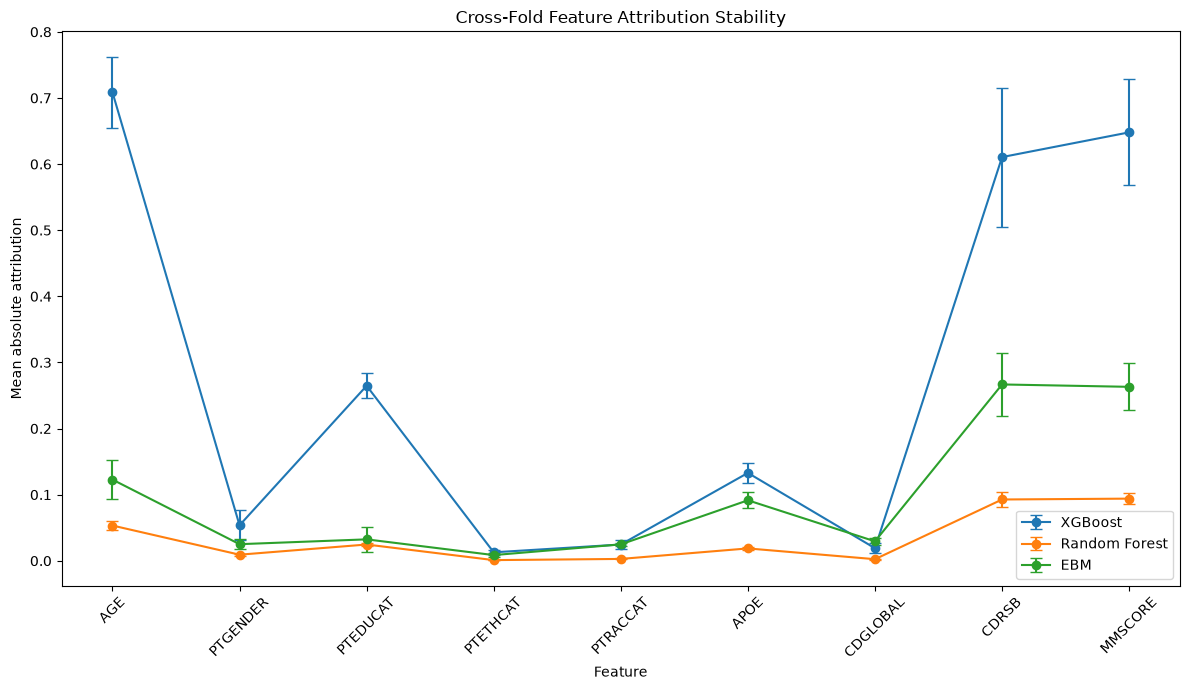

In [75]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 7))

for model in ["XGBoost", "Random Forest", "EBM"]:

    model_data = (
        stability_summary[
            stability_summary["Model"] == model
        ]
        .set_index("Feature")
        .reindex(primary_features)
    )

    ax.errorbar(
        primary_features,
        model_data["Mean"],
        yerr=model_data["SD"],
        marker="o",
        capsize=4,
        label=model
    )

ax.set_xlabel("Feature")
ax.set_ylabel("Mean absolute attribution")
ax.set_title(
    "Cross-Fold Feature Attribution Stability"
)

ax.tick_params(axis="x", rotation=45)
ax.legend()

plt.tight_layout()

plt.savefig(
    "../results/attribution_stability_final.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [76]:
final_xai_summary = pd.DataFrame({
    "Analysis": [
        "XGBoost vs Random Forest rank correlation",
        "XGBoost vs EBM rank correlation",
        "Random Forest vs EBM rank correlation",
        "Top-3 all-model Jaccard",
        "Top-5 all-model Jaccard",
        "XGBoost within-fold rank stability",
        "Random Forest within-fold rank stability",
        "EBM within-fold rank stability"
    ],
    "Value": [
        xgb_rf_rho,
        xgb_ebm_rho,
        rf_ebm_rho,
        top_k_consistency.loc[
            top_k_consistency["Top_K"] == 3,
            "Jaccard_All_Models"
        ].iloc[0],
        top_k_consistency.loc[
            top_k_consistency["Top_K"] == 5,
            "Jaccard_All_Models"
        ].iloc[0],
        0.9416666667,
        0.9800000000,
        0.8883333333
    ]
})

final_xai_summary["Value"] = final_xai_summary["Value"].round(4)

print("Final XAI summary:")
print(final_xai_summary)

Final XAI summary:
                                    Analysis   Value
0  XGBoost vs Random Forest rank correlation  0.9500
1            XGBoost vs EBM rank correlation  0.8667
2      Random Forest vs EBM rank correlation  0.9167
3                    Top-3 all-model Jaccard  1.0000
4                    Top-5 all-model Jaccard  1.0000
5         XGBoost within-fold rank stability  0.9417
6   Random Forest within-fold rank stability  0.9800
7             EBM within-fold rank stability  0.8883


In [77]:
final_xai_summary.to_csv(
    "../results/final_xai_summary.csv",
    index=False
)

print("Saved final XAI summary.")

Saved final XAI summary.
